In [236]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

In [237]:
df = pd.read_csv("../Data/Cleaned_data/Clean.csv")
df = df.set_index("Date_month")
df.index = pd.to_datetime(df.index)
df

,SP500_monthly_return,SP500_volatility,YOY_inflation,Inflation_volatility,Inflation_suprise,Inflation_lag,Volatility_lag,Surprise_lag
Date_month,,,,,,,,
2001-01-01,-2.429990,4.567131,3.721205,0.239086,0.721205,3.436019,0.286482,0.636019
2001-02-01,7.028914,5.041273,3.529412,0.229091,0.729412,3.721205,0.239086,0.721205
2001-03-01,-9.628168,5.732928,2.982456,0.248253,0.182456,3.529412,0.229091,0.729412
2001-04-01,-7.682701,5.115852,3.218256,0.224944,0.118256,2.982456,0.248253,0.182456
2001-05-01,10.522131,6.279052,3.563084,0.208416,0.363084,3.218256,0.224944,0.118256
...,...,...,...,...,...,...,...,...
2025-08-01,0.645368,3.235395,2.938592,0.232003,-1.861408,2.742618,0.213919,-1.757382
2025-09-01,2.845944,3.270414,3.022572,0.242695,-1.677428,2.938592,0.232003,-1.861408
2025-10-01,4.608500,3.366205,2.858718,0.243175,-1.741282,3.022572,0.242695,-1.677428


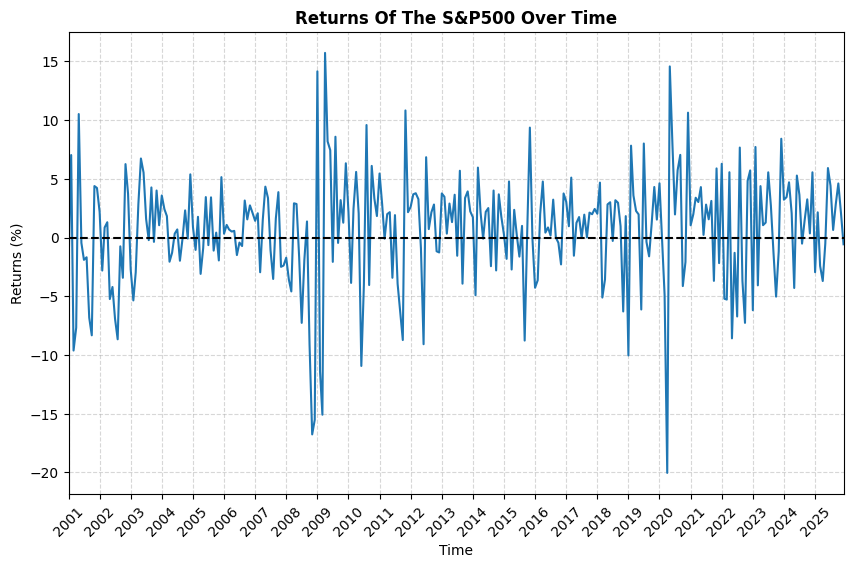

In [238]:
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.SP500_monthly_return)
plt.axhline(0, color="black", linestyle="dashed")
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Returns Of The S&P500 Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Returns (%)")
plt.grid(linestyle="--",alpha=0.5)

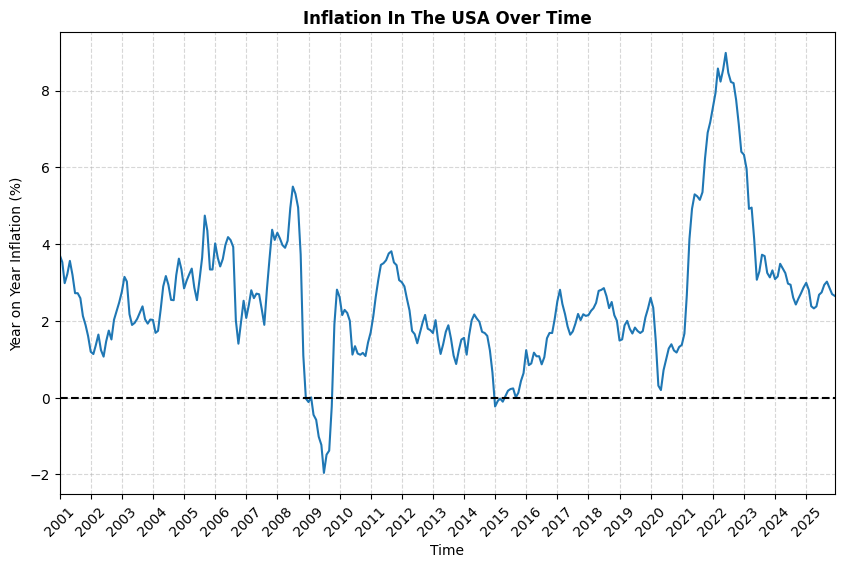

In [239]:
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.YOY_inflation)
plt.axhline(0, color="black", linestyle="dashed")
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Year on Year Inflation (%)")
plt.grid(linestyle="--",alpha=0.5)

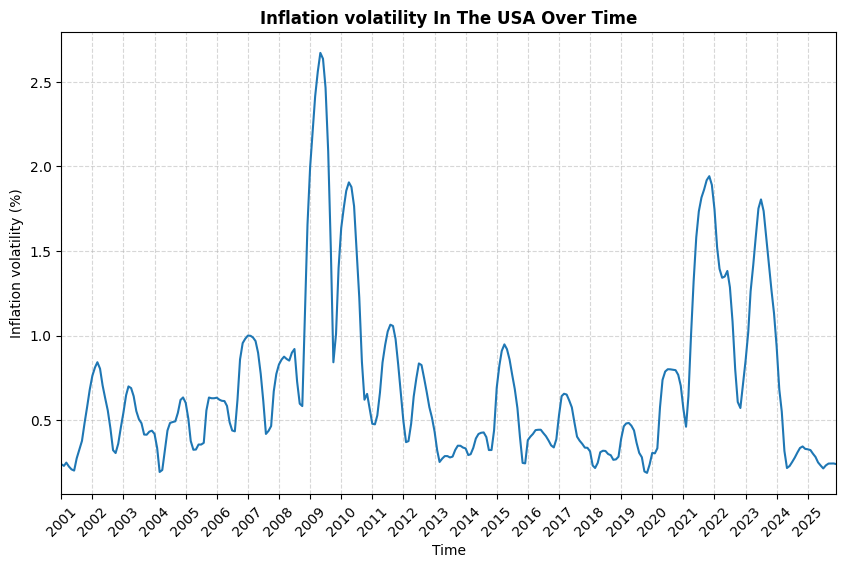

In [240]:
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_volatility)
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation volatility In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation volatility (%)")
plt.grid(linestyle="--",alpha=0.5)

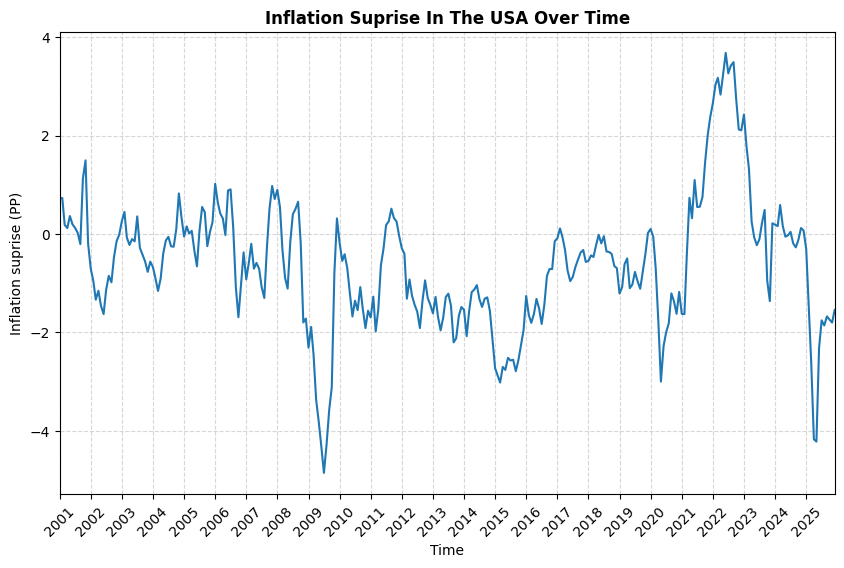

In [241]:
plt.figure(figsize=(10,6))
sns.lineplot(x=df.index, y=df.Inflation_suprise)
plt.xlim(df.index.min(), df.index.max())
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
plt.xticks(rotation=45)
plt.title("Inflation Suprise In The USA Over Time", weight="bold")
plt.xlabel("Time")
plt.ylabel("Inflation suprise (PP)")
plt.grid(linestyle="--",alpha=0.5)

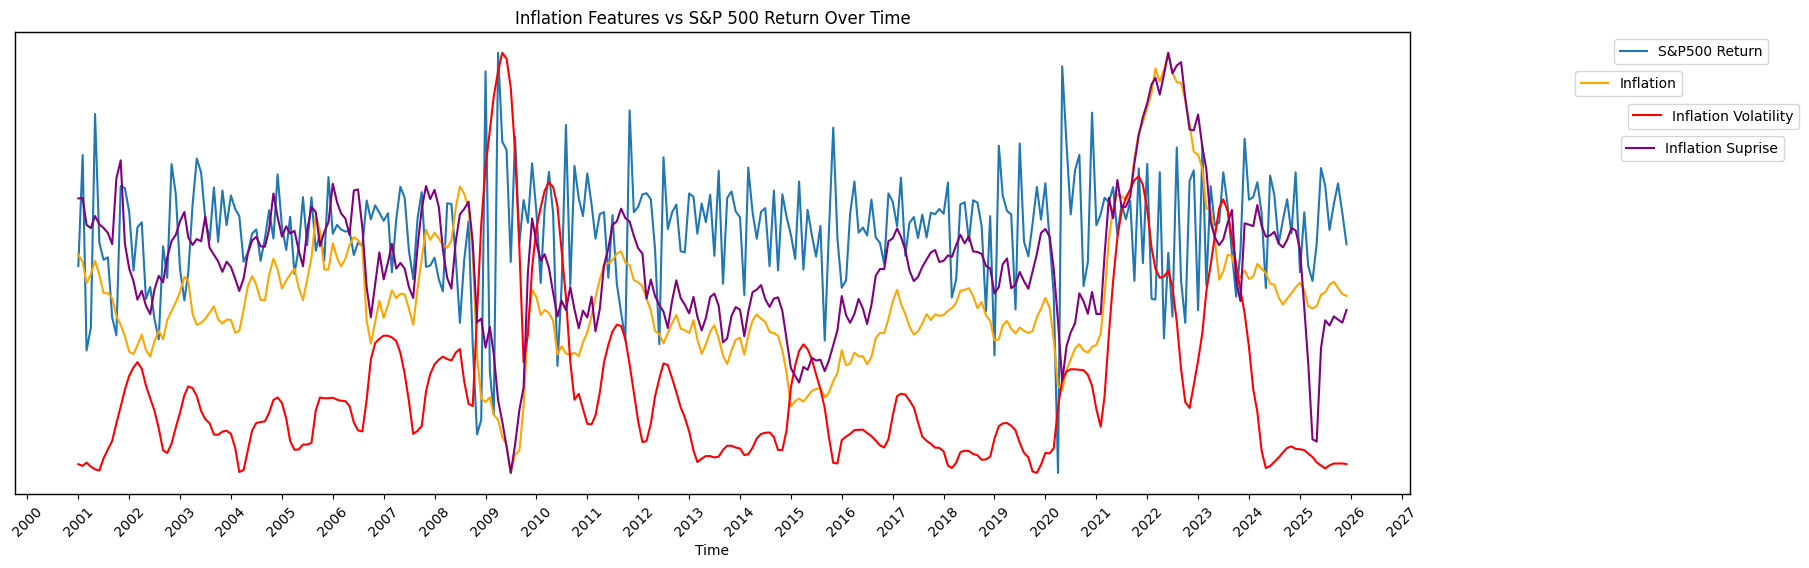

In [242]:
plt.figure(figsize=(18,6))
ax1 = sns.lineplot(x=df.index, y=df.SP500_monthly_return, label = "S&P500 Return")
ax1.grid(False)
ax1.set_ylabel("")
ax1.set_yticks([])
ax2 = ax1.twinx()
sns.lineplot(x=df.index, y=df.YOY_inflation, ax=ax2, color="orange", label = "Inflation")
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df.index, y=df.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility")
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df.index, y=df.Inflation_suprise, ax=ax4, color="purple", label = "Inflation Suprise")
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time")
ax1.legend(bbox_to_anchor=(1.262, 1))
ax2.legend(bbox_to_anchor=(1.2, 0.93))
ax3.legend(bbox_to_anchor=(1.284, 0.86))
ax4.legend(bbox_to_anchor=(1.273, 0.79))
plt.show()


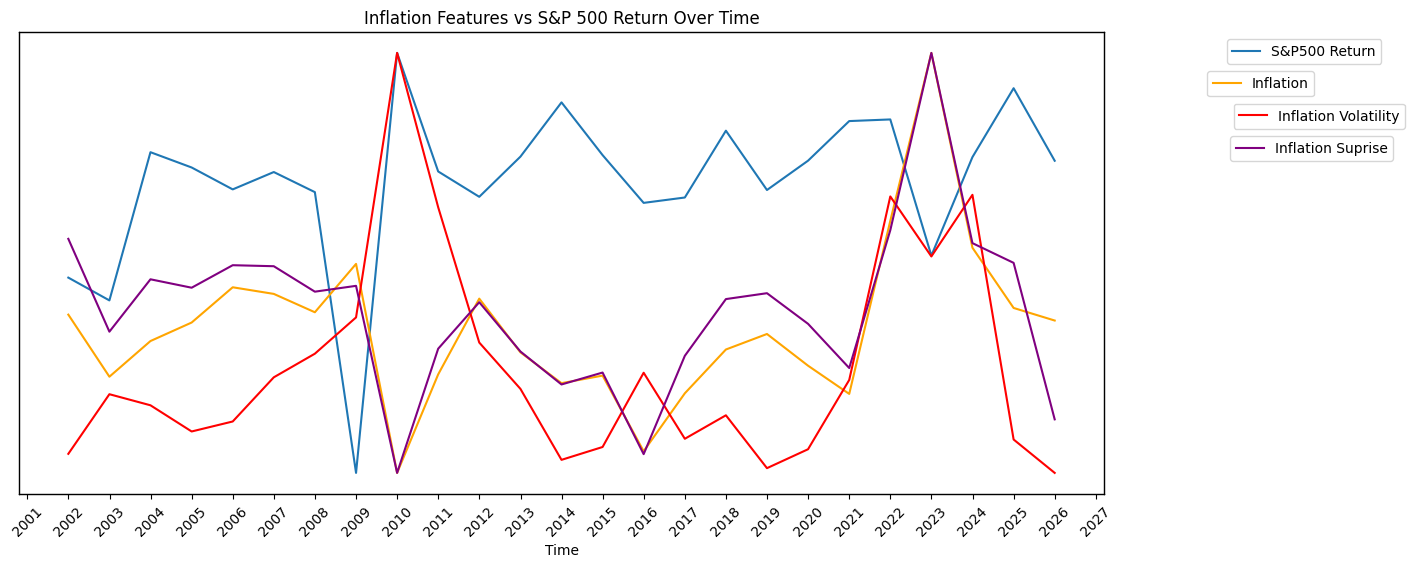

In [243]:
df_yearly = df.resample('YE').mean() #Decided to resample data to yearly data points since monthly values made the graph very cluttered

plt.figure(figsize=(14,6))
ax1 = sns.lineplot(x=df_yearly.index, y=df_yearly.SP500_monthly_return, label = "S&P500 Return")
ax1.grid(False)
ax1.set_ylabel("")
ax1.set_yticks([])
ax2 = ax1.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.YOY_inflation, ax=ax2, color="orange", label = "Inflation")
ax2.grid(False)
ax2.set_ylabel("")
ax2.set_yticks([])
ax3 = ax2.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_volatility, ax=ax3, color="red", label = "Inflation Volatility")
ax3.grid(False)
ax3.set_ylabel("")
ax3.set_yticks([])
ax4 = ax3.twinx()
sns.lineplot(x=df_yearly.index, y=df_yearly.Inflation_suprise, ax=ax4, color="purple", label = "Inflation Suprise")
ax4.grid(False)
ax4.set_ylabel("")
ax4.set_yticks([])
plt.gca().xaxis.set_major_locator(mdates.YearLocator(base=1))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel("Time")
plt.title("Inflation Features vs S&P 500 Return Over Time")
ax1.legend(bbox_to_anchor=(1.262, 1))
ax2.legend(bbox_to_anchor=(1.2, 0.93))
ax3.legend(bbox_to_anchor=(1.284, 0.86))
ax4.legend(bbox_to_anchor=(1.273, 0.79))
plt.show()


P value: 0.018716625864354658
R Value: -0.13568053361774296
R Squared Value: 0.01840920720279548


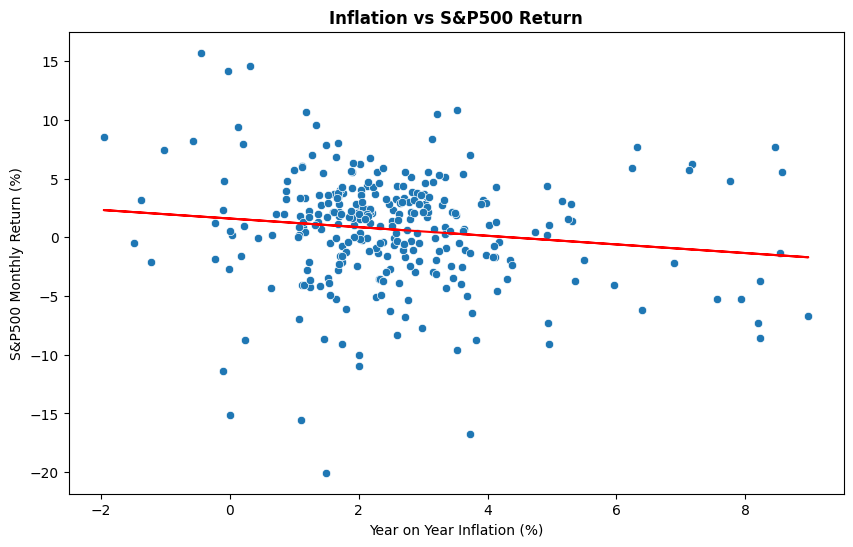

In [244]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_lag, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_lag, y=df.SP500_monthly_return)
plt.plot(df.Inflation_lag, slope * df.Inflation_lag + intercept, color="red")
plt.title("Inflation vs S&P500 Return", weight="bold")
plt.xlabel("Year on Year Inflation (%)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.6538015603368342
R Value: 0.02599757981505671
R Squared Value: 0.0006758741562402441


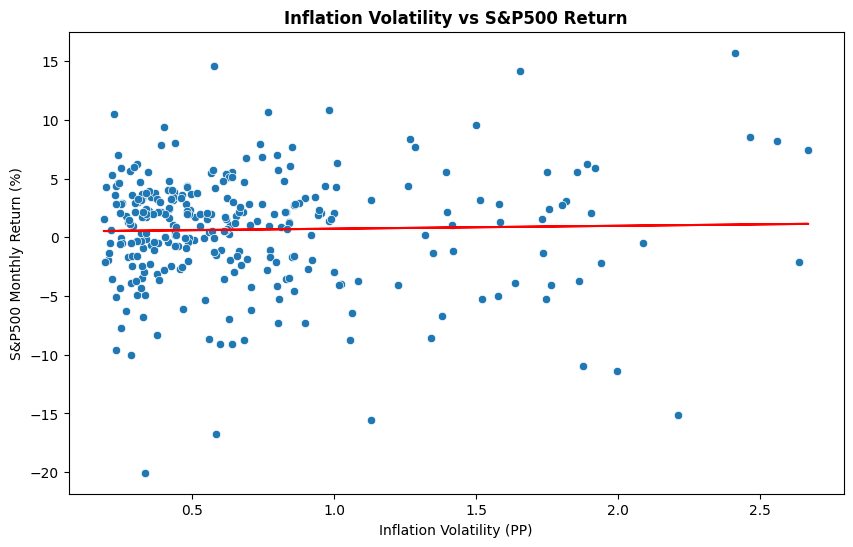

In [245]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Volatility_lag, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Volatility_lag, y=df.SP500_monthly_return)
plt.plot(df.Volatility_lag, slope * df.Volatility_lag + intercept, color="red")
plt.title("Inflation Volatility vs S&P500 Return", weight="bold")
plt.xlabel("Inflation Volatility (PP)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 0.019478151034265333
R Value: -0.13482992973581825
R Squared Value: 0.01817910995256569


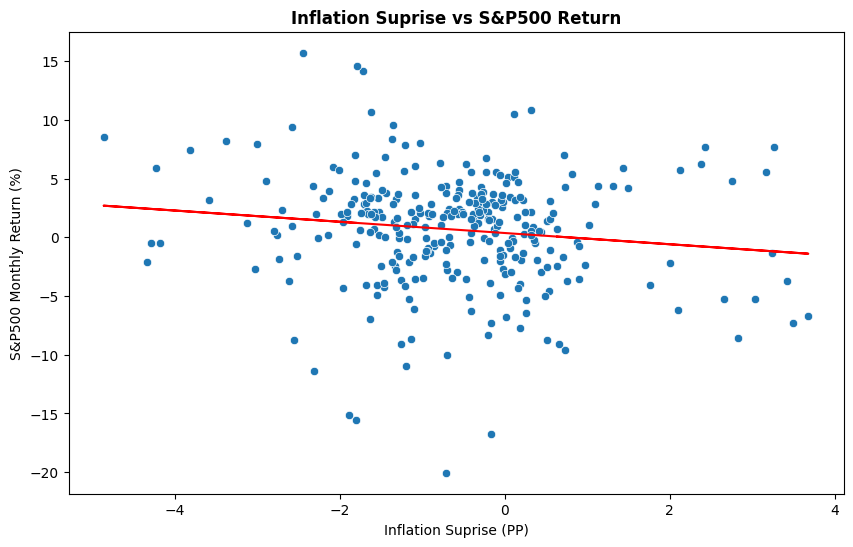

In [246]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Surprise_lag, y=df.SP500_monthly_return)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Surprise_lag, y=df.SP500_monthly_return)
plt.plot(df.Surprise_lag, slope * df.Surprise_lag + intercept, color="red")
plt.title("Inflation Suprise vs S&P500 Return", weight="bold")
plt.xlabel("Inflation Suprise (PP)")
plt.ylabel("S&P500 Monthly Return (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 7.507520248519086e-06
R Value: -0.2553484168356056
R Squared Value: 0.06520281398045019


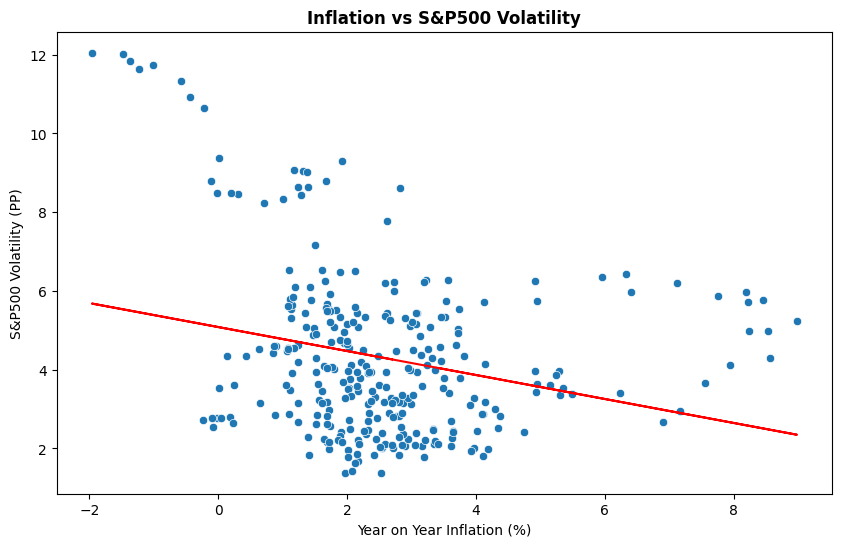

In [247]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Inflation_lag, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Inflation_lag, y=df.SP500_volatility)
plt.plot(df.Inflation_lag, slope * df.Inflation_lag + intercept, color="red")
plt.title("Inflation vs S&P500 Volatility", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Year on Year Inflation (%)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 3.488605582717696e-17
R Value: 0.46090235628781506
R Squared Value: 0.21243098203166003


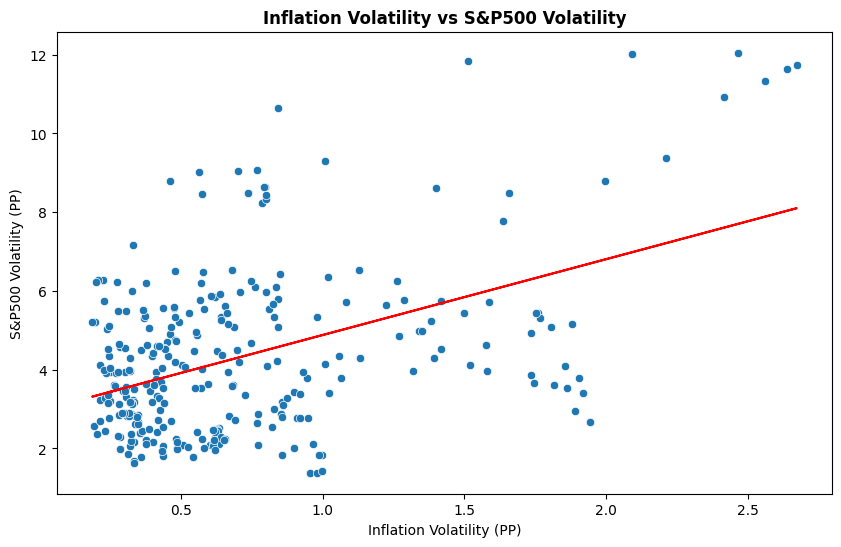

In [248]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Volatility_lag, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Volatility_lag, y=df.SP500_volatility)
plt.plot(df.Volatility_lag, slope * df.Volatility_lag + intercept, color="red")
plt.title("Inflation Volatility vs S&P500 Volatility", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Inflation Volatility (PP)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)

P value: 1.7614416514587365e-05
R Value: -0.24509820256504813
R Squared Value: 0.06007312890061737


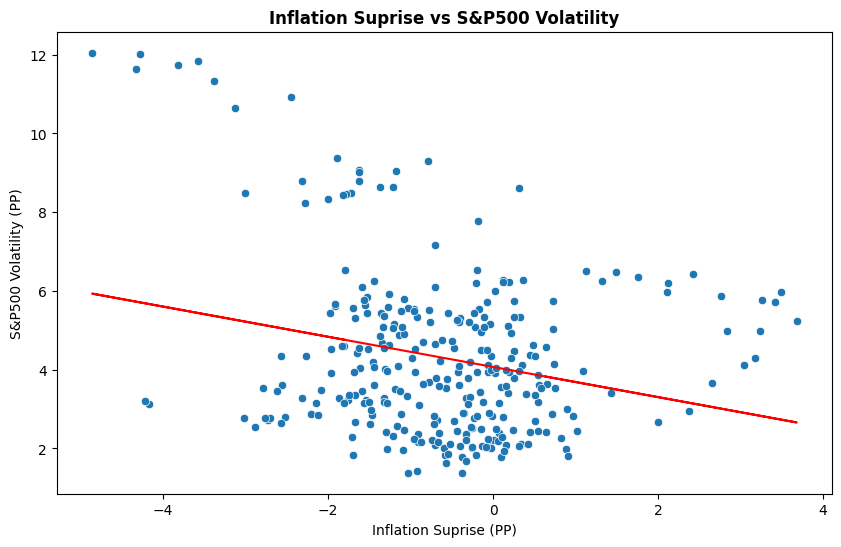

In [249]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df.Surprise_lag, y=df.SP500_volatility)
slope, intercept, rvalue, pvalue, std_error = stats.linregress(x=df.Surprise_lag, y=df.SP500_volatility)
plt.plot(df.Surprise_lag, slope * df.Surprise_lag + intercept, color="red")
plt.title("Inflation Suprise vs S&P500 Volatility", weight="bold")
plt.ylabel("S&P500 Volatility (PP)")
plt.xlabel("Inflation Suprise (PP)")

print("P value:", pvalue)
print("R Value:", rvalue)
print("R Squared Value:", rvalue**2)